In [3]:
import torch
import numpy as np

import os

from sklearn.decomposition import PCA
import seaborn as sns

In [4]:
output_path = '/data/scratch/hhy696/clipped_database/encoded/'
processed_files = os.listdir(output_path)

In [5]:
pooled_features = []
pooled_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name)
    data = data.mean(0)
    pooled_features.append(data.detach().numpy())


In [6]:
pooled_array = np.array(pooled_features)
pca = PCA(n_components=8)
pca_features = pca.fit_transform(pooled_array)

In [7]:
pca_features = []
pca_names = []
for file_name in processed_files:
    pooled_names.append(file_name)
    data = torch.load(output_path+file_name, weights_only=True)
    if data.shape[0] == 30:
        pca_names.append(file_name)
        data = pca.transform(data.detach().numpy())
        pca_features.append(data)

In [8]:
classes = []
for name in pca_names:
    classes.append(name.split('_')[1])
    
batches = []
for name in pca_names:
    batches.append(name.split('_')[0])
    

In [9]:
pca_features = np.array(pca_features)
pca_features.shape

(1625, 30, 8)

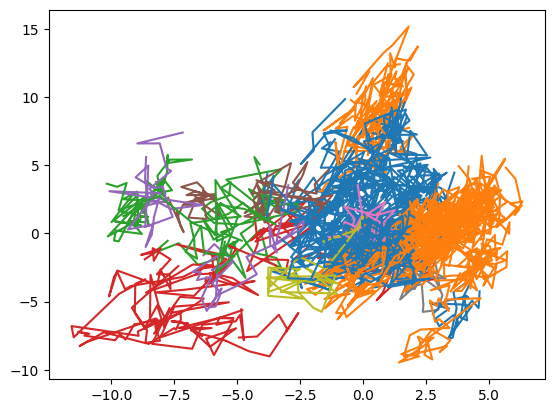

In [10]:
classhue = {'groom':sns.color_palette()[0], 
            'rest':sns.color_palette()[1],
            'eat':sns.color_palette()[2], 
            'hang':sns.color_palette()[3], 
            'rear':sns.color_palette()[4],
            'drink':sns.color_palette()[5],
            'head':sns.color_palette()[6],
            'groomback':sns.color_palette()[7],
            'walk':sns.color_palette()[8]}

for x in range(100,200):
    sns.lineplot(x = pca_features[x,:,2],y = pca_features[x,:,3],sort=False, color = classhue[classes[x]])


In [12]:
import umap
from sklearn.preprocessing import StandardScaler

/data/home/hhy696/.conda/envs/torchgpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

In [27]:
class autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim):
        super(autoencoder, self).__init__()
        
        # Number of hidden dimensions
        self.hidden_dim = hidden_dim
        
        # Number of input dimensions
        self.input_dim = input_dim
        
        # Number of hidden layers
        self.layer_dim = layer_dim
        
        # RNN
        self.rnn = nn.RNN(input_dim, hidden_dim, layer_dim, batch_first=True, nonlinearity='tanh',bidirectional=True)
        
        # CNN time compression
        self.conv1 = nn.Conv2d(1,hidden_dim, kernel_size = (2,hidden_dim*2), stride = (2,1))
        self.conv2 = nn.ConvTranspose2d(hidden_dim,1, kernel_size = (2,hidden_dim*2),stride = (2,1))
        
        # Readout layer
        self.rnn2 = nn.RNN(hidden_dim*2, input_dim, layer_dim, batch_first=True, nonlinearity='tanh',bidirectional=True)
    
    def forward(self, x):
        
        # Initialize hidden state with zeros
        h0 = Variable(torch.zeros(2 * self.layer_dim, x.size(0), self.hidden_dim)).cuda()
        h02 = Variable(torch.zeros(2 * self.layer_dim, x.size(0), self.input_dim)).cuda()
            
        # One time step
        out, hn = self.rnn(x, h0)
        out = self.conv1(out[:,None])
        out = self.conv2(out)[:,0]
        out, hn = self.rnn2(out, h02)
        out = out
        return out


In [28]:
# Create RNN
input_dim = 8    # input dimension
hidden_dim = 4  # hidden layer dimension
layer_dim = 1     # number of hidden layers


model = autoencoder(input_dim, hidden_dim, layer_dim).cuda()


In [29]:
a = model.rnn(torch.Tensor(pca_features).cuda())[0]
#model.conv1(a[:,None]).shape
model(torch.Tensor(pca_features).cuda()).shape

torch.Size([1625, 30, 16])

In [31]:
model(torch.Tensor(pca_features).cuda().shape

SyntaxError: incomplete input (52716.py, line 1)

In [32]:
X_train, X_test = train_test_split(
    torch.Tensor(pca_features), test_size=0.1, random_state=42)

In [33]:
X_train.shape

torch.Size([1462, 30, 8])

In [49]:
# batch_size, epoch and iteration
batch_size = 10000000
n_iters = 100000
num_epochs = n_iters / (len(X_train) / batch_size)
num_epochs = int(num_epochs)

# Pytorch train and test sets
train = TensorDataset(X_train)
test = TensorDataset(X_test)

# data loader
train_loader = DataLoader(train, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test, batch_size = batch_size, shuffle = False)

In [50]:
error = nn.MSELoss()
# SGD Optimizer
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [51]:
seq_dim = 30  
loss_list = []
iteration_list = []
accuracy_list = []
count = 0
for epoch in range(num_epochs):
    for i, images in enumerate(train_loader):
        images = images[0]
        train  = Variable(images.view(-1, seq_dim, input_dim))
            
        # Clear gradients
        optimizer.zero_grad()
        
        # Forward propagation
        outputs = model(train.cuda())
        
        # Calculate softmax and ross entropy loss
        loss = error(outputs[:,:,8:].cpu(), train/train.max())
        
        # Calculating gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        count += 1
        
        if count % 250 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images in test_loader:
                images = images[0]
                images = Variable(images.view(-1, seq_dim, input_dim))
                
                # Forward propagation
                outputs = model(images.cuda())
                accuracy = error(outputs[:,:,8:].cpu(), images/images.max())
            
            # store loss and iteration
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)
            if count % 500 == 0:
                # Print Loss
                print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 500  Loss: 0.015310163609683514  Accuracy: 0.016807153820991516 %
Iteration: 1000  Loss: 0.015279865823686123  Accuracy: 0.016773300245404243 %
Iteration: 1500  Loss: 0.015250439755618572  Accuracy: 0.01674002967774868 %
Iteration: 2000  Loss: 0.015221850946545601  Accuracy: 0.016706831753253937 %
Iteration: 2500  Loss: 0.015194031409919262  Accuracy: 0.01667601615190506 %
Iteration: 3000  Loss: 0.015166746452450752  Accuracy: 0.0166441909968853 %
Iteration: 3500  Loss: 0.015140319243073463  Accuracy: 0.016614072024822235 %
Iteration: 4000  Loss: 0.01511433906853199  Accuracy: 0.01658344641327858 %
Iteration: 4500  Loss: 0.015089083462953568  Accuracy: 0.016553863883018494 %
Iteration: 5000  Loss: 0.01506428886204958  Accuracy: 0.016524890437722206 %
Iteration: 5500  Loss: 0.015039918012917042  Accuracy: 0.016496233642101288 %
Iteration: 6000  Loss: 0.015015991404652596  Accuracy: 0.01646828092634678 %
Iteration: 6500  Loss: 0.014992434531450272  Accuracy: 0.0164396688342094

KeyboardInterrupt: 

In [ ]:
learning_rate = 0.002
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(num_epochs):
    for i, images in enumerate(train_loader):
        images = images[0]
        train  = Variable(images.view(-1, seq_dim, input_dim))
            
        # Clear gradients
        optimizer.zero_grad()
        
        # Forward propagation
        outputs = model(train)
        
        # Calculate softmax and ross entropy loss
        loss = error(outputs[:,:,8:], train/train.max())
        
        # Calculating gradients
        loss.backward()
        
        # Update parameters
        optimizer.step()
        
        count += 1
        
        if count % 250 == 0:
            # Calculate Accuracy         
            correct = 0
            total = 0
            # Iterate through test dataset
            for images in test_loader:
                images = images[0]
                images = Variable(images.view(-1, seq_dim, input_dim))
                
                # Forward propagation
                outputs = model(images)
                accuracy = error(outputs[:,:,8:], images/images.max())
            
            # store loss and iteration
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)
            if count % 500 == 0:
                # Print Loss
                print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

In [53]:
out = model.rnn(torch.tensor(pca_features).cuda())
out = out[1].cpu().detach().numpy()[0]

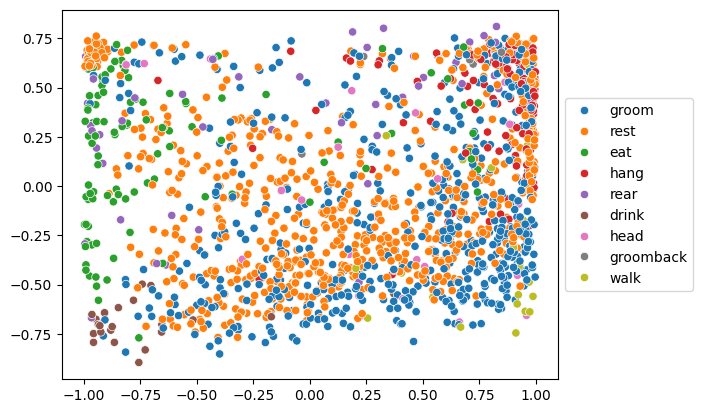

In [54]:
ax = sns.scatterplot(x = out[:,0],y = out[:,1], hue = classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

/data/home/hhy696/.conda/envs/torchgpu/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


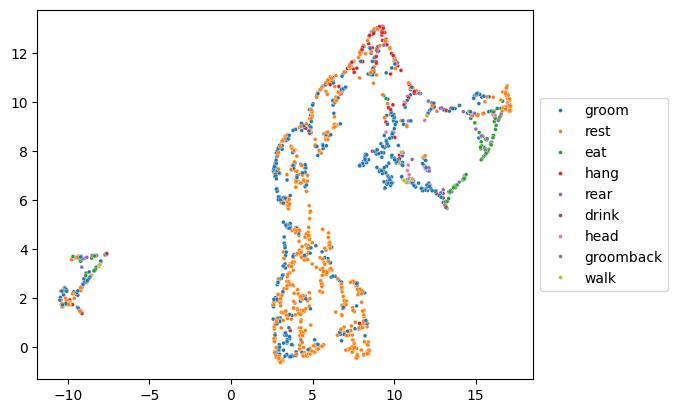

In [55]:
reducer = umap.UMAP()

scaled_features = StandardScaler().fit_transform(out)
embedding = reducer.fit_transform(scaled_features)
embedding.shape

ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=classes)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)

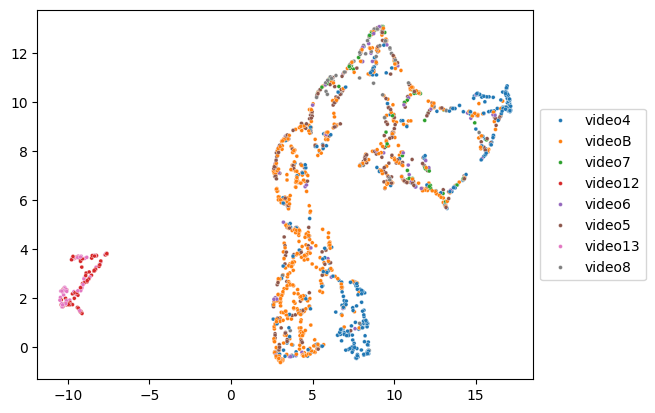

In [56]:
ax = sns.scatterplot(x = embedding[:,0],y = embedding[:,1], s=8,hue=batches)
ax.legend(loc = 'center left', bbox_to_anchor = (1, 0.5), ncol = 1)